### 🚀 Run this notebook in [RenkuLab](https://renkulab.io/)

👉 [![launch - renku](https://renkulab.io/renku-badge.svg)](https://renkulab.io/p/meteoswiss/opendata-nwp-demos/sessions/01KME52HC2FZ6ZHB30SSFG08PW/start)

1. Wait for the session to start
2. Navigate to `opendata-nwp-demos/11_analysis_data.ipynb` and run the notebook without any further installation.

# Retrieve and Visualize KENDA-CH1 Analysis Data

MeteoSwiss analysis data is produced using the [KENDA](https://www.meteoswiss.admin.ch/weather/warning-and-forecasting-systems/icon-forecasting-systems/ensemble-data-assimilation.html) (Kilometer-scale Ensemble Data Assimilation) system, which combines short-range forecasts with observations to estimate as accurately as possible the atmospheric state over Switzerland and its surroundings. This process is called data assimilation. The analysis is updated hourly and provides the initial conditions for numerical weather forecasts such as ICON-CH1-EPS and ICON-CH2-EPS.
The KENDA-CH1 analysis includes all standard parameters, which are also provided by MeteoSwiss numerical models ICON-CH1/2-EPS. 

This notebook demonstrates the full workflow for retrieving deterministic KENDA-CH1 wind gust analysis data and visualizing it. The data is provided by MeteoSwiss as part of Switzerland’s [Open Government Data (OGD) initiative](https://www.meteoswiss.admin.ch/services-and-publications/service/open-data.html).

The core functionality is powered by the [meteodata-lab](https://meteoswiss.github.io/meteodata-lab/) library — developed by MeteoSwiss to simplify working with numerical weather model data. It includes the `ogd_api` module for data access, along with utilities for applying temporal and spatial operators to model output, such as regridding.

For visualization, this notebook uses the [earthkit-plots](https://earthkit-plots.readthedocs.io/en/latest/examples/guide/01-introduction.html) library developed by ECMWF, which offers intuitive plotting tools for meteorological data.

---

## 🔍 **What You’ll Do in This Notebook**

 🛰️ **Retrieve**  
    Fetch deterministic KENDA-CH1 analysis data (here maximum wind gusts 10m above ground (`VMAX_10M`)) using [meteodata-lab](https://meteoswiss.github.io/meteodata-lab/)'s `ogd_api` module.

 🧭 **Regrid**  
    Interpolate KENDA-CH1 data from its native, icosahedral grid to the regular latitude/longitude grid [WGS84 (EPSG:4326)](https://epsg.io/4326).

 🌍 **Visualize**  
    Plot the processed data on a map using [earthkit-plots](https://earthkit-plots.readthedocs.io/en/latest/examples/guide/01-introduction.html).

---

## Retrieving Analysis Data

We distinguish between two types of analysis data: instantaneous fields at the assimilation time step and aggregated fields over the 1h short-term ICON forecasts ran between assimilation time steps. Instantaneous fields describe the atmospheric state at a specific reference time, including variables such as temperature, wind, and pressure. Those are a direct output of the analysis computed by the KENDA system. In contrast, aggregated fields represent quantities that are accumulated, averaged, minimized, or maximized over a given time period and therefore cannot be defined at a single instant. Those are not updated directly by the KENDA system and are therefore taken from the ICON forecasts ran in the assimilation cycle (so-called first guess runs). For further details, see [Numerical weather analysis KENDA-CH1](https://opendatadocs.meteoswiss.ch/e-forecast-data/e5-numerical-weather-analysis-data).

In this first part, we retrieve the deterministic output of maximum wind gusts produced by KENDA-CH1. This parameter is part of the first-guess fields. To access this data, we use the `ogd_api` module from the [meteodata-lab](https://meteoswiss.github.io/meteodata-lab/) library — a convenient interface for retrieving numerical weather analysis data via the [STAC (SpatioTemporal Asset Catalog) API](https://data.geo.admin.ch/api/stac/static/spec/v1/apitransactional.html#tag/Data/operation/getAsset), which provides structured access to Switzerland’s open geospatial data.

#### 📁  Browsing the STAC Catalog (Optional)

If you'd like to explore the KENDA-CH1 analysis datasets interactively before writing code, you can browse them directly in the STAC catalog:

&nbsp;&nbsp;&nbsp;&nbsp;🔗  [Browse the KENDA-CH1 collection](https://data.geo.admin.ch/browser/#/collections/ch.meteoschweiz.ogd-analysis-kenda-ch1?.language=en)

Below is a screenshot of the KENDA-CH1 collection as seen in the STAC browser interface.


![browser-ch2.png](./images/browser-ch2.png) #TODO: Add Analysis Data Image

### Creating Requests
To retrieve the analysis data, we first define an API request using the `ogd_api.Request` class. In this example, we create a request to access maximum wind gusts 10 meter above ground (`VMAX_10M`). The request targets deterministic output at lead time +1 hour, which corresponds to the length of a first guess run in the KENDA system.

>⏰ **Analysis Availability**: Analysis data will typically be available a couple of hours after the reference time — due to the model runtime and subsequent upload time. The data remains accessible for 24 hours after upload.

In [1]:
from meteodata.src.meteodatalab import ogd_api


req = ogd_api.Request(
    collection="ogd-analysis-kenda-ch1",
    variable="VMAX_10M",
    ref_time="latest",
    perturbed=False,
    lead_time="P0DT1H",
)

Each argument in the request serves the following purpose:

| Argument             | Description |
|----------------------|-------------|
| `collection`         | Collection to use (e.g., `ogd-analysis-kenda-ch1`). |
| `variable`           | Meteorological variable of interest (`VMAX_10M` = 10 meter maximum wind gusts). |
| `ref_time` | Initialization time of the forecast in **UTC**, provided as either:<br>- The string `"latest"` to select the most recent available run (`ref_time`) for each requested asset. Be cautious: since each asset covers one model, ref_time, lead time, and variable, so multiple requests during data publication may return assets with different `ref_time` values. <br>- [datetime.datetime](https://docs.python.org/3/library/datetime.html#datetime-objects) object (e.g.,<br> &nbsp; `datetime.datetime(2025, 5, 22, 9, 0, 0, tzinfo=datetime.timezone.utc)`) <br>- [ISO 8601](https://en.wikipedia.org/wiki/ISO_8601#Combined_date_and_time_representations) date string (e.g., `"2025-05-22T09:00:00Z"`)|
| `perturbed`          | If `True`, retrieves ensemble forecast members; if `False`, returns the deterministic forecast. |
| `lead_time`            | Forecast lead time, provided as either:<br>– [datetime.timedelta](https://docs.python.org/3/library/datetime.html#timedelta-objects) object (e.g., `datetime.timedelta(hours=1)`) <br>– [ISO 8601](https://en.wikipedia.org/wiki/ISO_8601#Durations) duration string (e.g., `"P0DT1H"`)|

### Retrieving Data
We now send our request to the API and retrieve the resulting dataset using the `get_from_ogd()` function.
Each response is returned as an **[xarray.DataArray](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html)**, which is efficient for handling multi-dimensional data.

> 💡 **Tip**: Use temporary caching with earthkit-data to skip repeated downloads — it's auto-cleaned after the session.
> *For more details, see the [earthkit-data caching docs](https://earthkit-data.readthedocs.io/en/latest/examples/cache.html)*.

> 💡 **Hint**: If you get an error message containing `HTTPError: 403 Client Error: Forbidden for url`, you may be trying to retrieve data older than 24h hours! Please adjust your requests.

In [2]:
from earthkit.data import config
config.set("cache-policy", "temporary")


da = ogd_api.get_from_ogd(req)

## Regridding to the Regular Grid [WGS84](https://epsg.io/4326)

Once the data has been loaded, continue with the regridding. To visualize or compare KENDA-CH1 outputs with other datasets, it is often necessary to regrid the data from its native unstructured grid to a regular latitude/longitude grid.

This can be done using the `regrid` utilities provided by [meteodata-lab](https://meteoswiss.github.io/meteodata-lab/).

We begin by defining a **target grid**, starting with its **spatial extent**, also known as the bounding box. This is specified by the minimum and maximum coordinate values along the x and y axes (commonly referred to as longitude and latitude when using a geographic CRS such as [WGS84 (EPSG:4326)](https://epsg.io/4326)). Note that in projected coordinate systems, these values are not technically “longitude” and “latitude,” but rather x and y coordinates in the chosen CRS.

In this example, we use the `regrid.iconremap()` function to perform the regridding. Depending on how the target grid's spatial extent is defined, it can fall into one of the following cases:
  - ✅ **Fully overlap** the ICON-CH1/CH2-EPS domain: all target grid points are interpolated.
  - ⚠️ **Partially overlap**: only the overlapping area will contain valid values; other points are filled with `NaN`.
  - ❌ **Lie completely outside** the ICON-CH1/CH2-EPS domain: all target grid values will be `NaN`.

📌 In our example, we define the spatial extent to fully match the **ICON-CH1-EPS** domain, which matches the KENDA-CH1 domain.

<p align="center">
  <img src="images/icon-ch1-ch2-eps-domain.png" alt="ICON domain illustration" width="450"/>
</p>

In [ ]:
from rasterio.crs import CRS
from meteodatalab.operators import regrid

# Define ~1 km target grid over ICON-CH1-EPS domain
extent = (-0.817, 18.183, 41.183, 51.183)  # (xmin, xmax, ymin, ymax)
nx, ny = 429, 295

# Create regular lat/lon grid (EPSG:4326) and regrid
destination = regrid.RegularGrid(CRS.from_epsg(4326), nx, ny, *extent)
da_geo = regrid.iconremap(da, destination)
da_geo

## 🗺️ Plot maximum wind gusts 10 meter above ground

/home/nen/.cache/pypoetry/virtualenvs/opendata-nwp-demos-hMmUcv8Z-py3.11/lib/python3.11/site-packages/earthkit/plots/styles/__init__.py:504: UserWarning: The following kwargs were not used by contour: 'transform_first'
  return ax.tricontourf(x, y, values, *args, **kwargs)
/home/nen/.cache/pypoetry/virtualenvs/opendata-nwp-demos-hMmUcv8Z-py3.11/lib/python3.11/site-packages/earthkit/plots/styles/__init__.py:483: UserWarning: The following kwargs were not used by contour: 'transform_first'
  return ax.tricontour(x, y, values, *args, **kwargs)
/home/nen/.cache/pypoetry/virtualenvs/opendata-nwp-demos-hMmUcv8Z-py3.11/lib/python3.11/site-packages/earthkit/plots/metadata/labels.py:131: UserWarning: No key "variable_name" found in layer metadata.
  warnings.warn(f'No key "{attr}" found in layer metadata.')


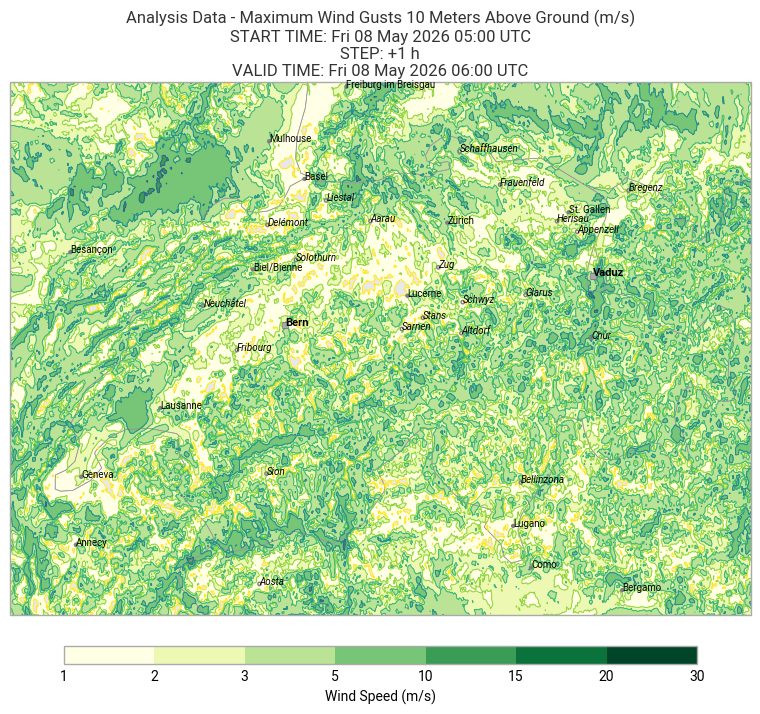

In [3]:
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
from earthkit.plots.geo import bounds, domains
from earthkit.plots.styles import Style, Contour
import earthkit


# === Setup Domain (Switzerland) ===
bbox = bounds.BoundingBox(5.7, 10.5, 45.6, 48, ccrs.Geodetic())
domain = domains.Domain.from_bbox(bbox=bbox)

# === Define Style ===
levels = [1, 2, 3, 5, 10, 15, 20, 30]

contourf_style = Style(
    levels=levels,
    colors="YlGn",
    legend_style="colorbar",
)


contour_style = Contour(
    levels=levels,
    legend_style=None
)

# === Create Map ===
chart = earthkit.plots.Map(domain=domain)

# Plot filled contours and line contours
chart.contourf(da, x="lon", y="lat", style=contourf_style)
chart.contour(da, x="lon", y="lat", style=contour_style)

# Add map features
chart.borders()
chart.cities("high")
chart.land()
chart.legend(label="Wind Speed (m/s)")

# === Title Setup ===
# Extract reference and lead time
ref_time = pd.to_datetime(da.coords["ref_time"].values[0])
lead_time = da.coords["lead_time"].values[0]
lead_hours = int(lead_time.astype("timedelta64[h]") / np.timedelta64(1, "h"))
valid_time = ref_time + pd.to_timedelta(lead_hours, unit="h")

# Format and apply title
title_text = "\n".join([
    "Analysis Data - Maximum Wind Gusts 10 Meters Above Ground (m/s)",
    f"START TIME: {ref_time.strftime('%a %d %b %Y %H:%M')} UTC",
    f"STEP: +{lead_hours} h",
    f"VALID TIME: {valid_time.strftime('%a %d %b %Y %H:%M')} UTC"
])
chart.title(text=title_text)

# === Show Plot ===
chart.show()
